# Challenge 03 — Fase 1: Data Understanding y Geo-Visualización

**TechLogistics S.A.** | Maestría en Ciencia de Datos - EAFIT | Periodo 2026-1

Esta fase cubre las dos tareas asignadas dentro del Challenge 03:

1. **Tarea 1 — Exploración Geo-Temporal:** visualización espacial de la red de
   sensores agroindustriales (`agro_clean.csv`) codificando NDVI y Humedad.
2. **Tarea 2 — Análisis de Estacionariedad y Windowing:** diagnóstico ADF sobre
   las series de energía (`ener_clean.csv`), con ventana móvil para las series
   no estacionarias y análisis de Drift vs. Random Walk en `Ener_5`.


In [144]:
import pandas as pd
import numpy as np
import plotly.express as px
from statsmodels.tsa.stattools import adfuller, kpss

pd.set_option('display.max_columns', None)


## Tarea 1: Exploración Geo-Temporal

Cargamos `agro_clean.csv`. Cada fila representa una lectura de un sensor
agroindustrial en el Oriente Antioqueño, georreferenciada con `Latitude` y
`Longitude`, y conectada a un `Target_Node` (gateway) dentro de la red mesh.


In [145]:
agro = pd.read_csv('../data/raw/agro_clean.csv')
print(agro.shape)
agro.head()


(2000, 14)


,Agro_1,Agro_2,Agro_3,Agro_4,Agro_5,Agro_6,Agro_7,Agro_8,Agro_9,Agro_10,Latitude,Longitude,Source_Node,Target_Node
0,60.248357,47.797447,65.395554,0.000000,0.478718,2.498349,10.000000,6.432151,1.258741,4.663639,6.203680,-75.400366,4,17
1,60.080940,48.076702,66.143237,25.002075,0.467100,2.473166,10.006672,6.469450,1.106051,4.683748,6.282310,-75.474525,14,21
2,60.623974,48.002378,66.342755,49.941596,0.449259,2.464547,10.013349,6.440262,1.183610,8.353141,6.165190,-75.476937,14,22
3,61.211672,48.267738,66.826015,74.756163,0.439299,2.500284,10.020030,6.511042,1.197917,6.213966,6.131334,-75.468152,8,25
4,60.483063,47.912028,65.703353,99.383693,0.436016,2.564177,10.026716,6.619718,1.200795,8.720976,6.241746,-75.349805,5,26


### Estructura del DataFrame

Antes de meternos en el análisis, miramos con `info()` la estructura de `agro_clean.csv`: tipos de
columna y valores no nulos.

In [146]:
agro.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Agro_1       2000 non-null   float64
 1   Agro_2       2000 non-null   float64
 2   Agro_3       2000 non-null   float64
 3   Agro_4       2000 non-null   float64
 4   Agro_5       2000 non-null   float64
 5   Agro_6       2000 non-null   float64
 6   Agro_7       2000 non-null   float64
 7   Agro_8       2000 non-null   float64
 8   Agro_9       2000 non-null   float64
 9   Agro_10      2000 non-null   float64
 10  Latitude     2000 non-null   float64
 11  Longitude    2000 non-null   float64
 12  Source_Node  2000 non-null   int64  
 13  Target_Node  2000 non-null   int64  
dtypes: float64(12), int64(2)
memory usage: 218.9 KB


### Perfilamiento rápido

Antes de visualizar, confirmamos que no hay nulos ni duplicados evidentes
(según el enunciado, esta versión `clean` no debería tenerlos).


In [147]:
print("Nulos por columna:")
print(agro.isna().sum())
print("\nFilas duplicadas:", agro.duplicated().sum())
print("\nSensores únicos (Source_Node):", agro['Source_Node'].nunique())
print("Gateways únicos (Target_Node):", agro['Target_Node'].nunique())


Nulos por columna:
Agro_1         0
Agro_2         0
Agro_3         0
Agro_4         0
Agro_5         0
Agro_6         0
Agro_7         0
Agro_8         0
Agro_9         0
Agro_10        0
Latitude       0
Longitude      0
Source_Node    0
Target_Node    0
dtype: int64

Filas duplicadas: 0

Sensores únicos (Source_Node): 14
Gateways únicos (Target_Node): 15


### Mapa geoespacial: color = NDVI (Agro_5), tamaño = Humedad (Agro_1)

Usamos `scatter_mapbox` de Plotly Express. Como cada sensor tiene múltiples
lecturas en el tiempo, primero agregamos por `Source_Node` (promedio de NDVI
y Humedad, y su ubicación) para tener **un punto por sensor** en el mapa —
graficar cada lectura individual saturaría el mapa sin aportar señal espacial
adicional.


In [148]:
agro_geo = (
    agro.groupby('Source_Node')
    .agg(
        Latitude=('Latitude', 'mean'),
        Longitude=('Longitude', 'mean'),
        NDVI=('Agro_5', 'mean'),
        Humedad=('Agro_1', 'mean'),
        Target_Node=('Target_Node', lambda x: x.mode()[0]),
    )
    .reset_index()
)
agro_geo.head()


,Source_Node,Latitude,Longitude,NDVI,Humedad,Target_Node
0,1,6.201189,-75.400394,1.134482,61.303896,17
1,2,6.201115,-75.395744,1.158621,61.185142,16
2,3,6.198764,-75.404026,1.200254,60.859097,20
3,4,6.201792,-75.394481,1.185135,60.961797,19
4,5,6.202941,-75.402092,1.117531,60.846702,19


### Mapa interactivo con Plotly

Construimos el mapa con `scatter_mapbox` usando los promedios por sensor: el color de cada punto es
el NDVI (`Agro_5`) y el tamaño la humedad (`Agro_1`).

In [149]:
fig = px.scatter_mapbox(
    agro_geo,
    lat='Latitude',
    lon='Longitude',
    color='NDVI',
    size='Humedad',
    hover_name='Source_Node',
    hover_data={'Target_Node': True, 'NDVI': ':.3f', 'Humedad': ':.2f'},
    color_continuous_scale='RdYlGn',
    size_max=25,
    zoom=9,
    height=600,
    title='Red de Sensores Agroindustriales — Color: NDVI | Tamaño: Humedad',
)
fig.update_layout(mapbox_style='open-street-map')
fig.update_layout(margin={'r': 0, 't': 40, 'l': 0, 'b': 0})
fig.write_html('../results/figuras/mapa_agro_ndvi_humedad.html', auto_open=False)
fig.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20460\3566232451.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


### Análisis: ¿hay clustering espacial de biomasa baja?

Para responder de forma objetiva (no solo visual), calculamos el umbral del
cuartil inferior de NDVI y revisamos si los sensores por debajo de ese umbral
se concentran geográficamente (distancia promedio entre ellos vs. distancia
promedio general).


In [150]:
q1_ndvi = agro_geo['NDVI'].quantile(0.25)
bajo_ndvi = agro_geo[agro_geo['NDVI'] <= q1_ndvi].copy()
print(f"Umbral Q1 de NDVI: {q1_ndvi:.3f}")
print(f"Sensores con NDVI bajo (<= Q1): {len(bajo_ndvi)} de {len(agro_geo)}")
bajo_ndvi[['Source_Node', 'Latitude', 'Longitude', 'NDVI', 'Humedad']].sort_values('NDVI')


Umbral Q1 de NDVI: 1.137
Sensores con NDVI bajo (<= Q1): 4 de 14


,Source_Node,Latitude,Longitude,NDVI,Humedad
13,14,6.205431,-75.404362,1.105670,61.389763
9,10,6.200163,-75.392642,1.117056,60.312579
4,5,6.202941,-75.402092,1.117531,60.846702
0,1,6.201189,-75.400394,1.134482,61.303896


**Nota metodológica:** usar distancia euclidiana directa sobre grados de
latitud/longitud es incorrecto — un grado de longitud no equivale a la misma
distancia real que un grado de latitud (la equivalencia depende del coseno de
la latitud), y con pocos puntos ese sesgo puede voltear la conclusión.
Usamos la fórmula de **Haversine** para obtener distancias reales en metros
sobre la superficie terrestre.


In [151]:
from itertools import combinations

def haversine(p1, p2):
    """Distancia en metros entre dos puntos (lat, lon) sobre la Tierra."""
    lat1, lon1 = p1
    lat2, lon2 = p2
    R = 6371000  # radio terrestre en metros
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


### Inspección por pares: ¿todos los sensores de NDVI bajo están agrupados, o solo algunos?

Un promedio agregado de distancias sobre el grupo completo no es una métrica
útil aquí: con solo 4 puntos, un único sensor alejado infla el promedio y
puede ocultar que el resto sí esté agrupado. Por eso miramos directamente la
matriz de distancias par a par entre los sensores de NDVI bajo.


In [152]:
nodos_bajo = list(zip(bajo_ndvi['Source_Node'], zip(bajo_ndvi['Latitude'], bajo_ndvi['Longitude'])))

print(f"{'Nodo A':>8} {'Nodo B':>8} {'Distancia (m)':>15}")
pares = []
for (n1, c1), (n2, c2) in combinations(nodos_bajo, 2):
    d = haversine(c1, c2)
    pares.append((n1, n2, d))
    print(f"{n1:>8} {n2:>8} {d:>15.1f}")

pares_df = pd.DataFrame(pares, columns=['Nodo_A', 'Nodo_B', 'Distancia_m']).sort_values('Distancia_m')
pares_df


  Nodo A   Nodo B   Distancia (m)
       1        5           270.6
       1       10           864.5
       1       14           644.1
       5       10          1089.4
       5       14           373.6
      10       14          1421.8


,Nodo_A,Nodo_B,Distancia_m
0,1,5,270.589413
4,5,14,373.590916
2,1,14,644.105813
1,1,10,864.453923
3,5,10,1089.383127
5,10,14,1421.780978


**Conclusión Tarea 1:** la matriz de distancias por pares confirma un
**clúster compacto entre los nodos 14, 5 y 1** (distancias de ~270 a ~644 m
entre ellos), mientras que el **nodo 10 es un outlier aislado** respecto a
ese grupo (~865-1,420 m de distancia).

**Interpretación de negocio:** la zona donde se ubican los nodos 14, 5 y 1 es
la candidata prioritaria para inversión en infraestructura hídrica (pregunta
de negocio P2 de la Fase 4) — ahí sí hay un patrón geográfico de biomasa
baja, no solo fallas puntuales de sensor. El nodo 10 debe tratarse por
separado: su NDVI bajo parece ser un caso aislado, posiblemente ligado a una
condición local del sensor/cultivo más que a la zona.


## Tarea 2: Análisis de Estacionariedad y Windowing

Cargamos `ener_clean.csv`. El diccionario de datos etiqueta explícitamente:
- `Ener_5-7` (Costo de Gas, Emisiones CO2, etc.): **No Estacionarias**.
- `Ener_8-10` (Frecuencia, Voltaje, Factor de Potencia): **Estacionarias**.

Para `Ener_1-3` (Demanda, Precio, Temperatura) el diccionario solo indica que
tienen correlación alta entre sí, sin pronunciarse sobre estacionariedad —
por eso el ADF/KPSS sobre esas tres variables es exploratorio, no una
verificación de algo ya anunciado.

El test ADF nos permite confirmar empíricamente las expectativas del
diccionario y, de paso, diagnosticar lo que no estaba anunciado.


In [153]:
ener = pd.read_csv('../data/raw/ener_clean.csv')
print(ener.shape)
ener.head()


(2000, 14)


,Ener_1,Ener_2,Ener_3,Ener_4,Ener_5,Ener_6,Ener_7,Ener_8,Ener_9,Ener_10,Latitude,Longitude,Source_Node,Target_Node
0,117.538413,169.976747,31.052273,40.000000,5.035559,999.997980,500.382001,60.007129,109.525783,0.952104,6.772983,-75.450170,106,244
1,123.085137,178.287791,30.367913,40.001201,4.964209,1000.012288,499.156777,60.010171,109.396517,0.963803,6.817829,-76.987525,113,241
2,122.444639,178.064846,29.483741,40.004804,4.885030,1000.185140,499.276252,59.998643,110.560808,0.939290,5.519644,-73.757957,105,233
3,117.595897,175.257364,29.985873,40.010804,5.039720,1000.075905,499.093300,59.994357,109.234773,0.945306,8.788327,-73.611230,105,237
4,123.471177,186.082293,30.359202,40.019198,5.046006,999.714688,499.380771,59.955593,110.202660,0.951658,8.450681,-73.456254,108,206


### Estructura del dataset de energía

Al igual que con el agro, revisamos la estructura de `ener_clean.csv` con `info()` para confirmar
tipos y ausencia de nulos.

In [154]:
ener.info()
print("\nNulos por columna:")
print(ener.isna().sum())
print("\nFilas duplicadas:", ener.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Ener_1       2000 non-null   float64
 1   Ener_2       2000 non-null   float64
 2   Ener_3       2000 non-null   float64
 3   Ener_4       2000 non-null   float64
 4   Ener_5       2000 non-null   float64
 5   Ener_6       2000 non-null   float64
 6   Ener_7       2000 non-null   float64
 7   Ener_8       2000 non-null   float64
 8   Ener_9       2000 non-null   float64
 9   Ener_10      2000 non-null   float64
 10  Latitude     2000 non-null   float64
 11  Longitude    2000 non-null   float64
 12  Source_Node  2000 non-null   int64  
 13  Target_Node  2000 non-null   int64  
dtypes: float64(12), int64(2)
memory usage: 218.9 KB

Nulos por columna:
Ener_1         0
Ener_2         0
Ener_3         0
Ener_4         0
Ener_5         0
Ener_6         0
Ener_7         0
Ener_8         0
Ener_9      

### Test ADF sobre todas las series `Ener_1` a `Ener_10`

- **H0:** la serie tiene raíz unitaria → no estacionaria.
- **H1:** la serie es estacionaria.
- Regla: si `p-value < 0.05` → rechazamos H0 → **estacionaria (I(0))**.

Complementamos con **KPSS** (hipótesis nula invertida: H0 = estacionaria) para
tener un diagnóstico cruzado más robusto, especialmente en los casos donde
ADF dé un resultado ambiguo.


In [155]:
def diagnostico_estacionariedad(serie, nombre):
    adf_stat, adf_p, *_ = adfuller(serie.dropna(), autolag='AIC')

    # KPSS puede lanzar warning de interpolación en los p-values extremos; lo ignoramos aquí
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, *_ = kpss(serie.dropna(), regression='c', nlags='auto')

    adf_concl = 'Estacionaria' if adf_p < 0.05 else 'No Estacionaria'
    kpss_concl = 'No Estacionaria' if kpss_p < 0.05 else 'Estacionaria'

    return {
        'Variable': nombre,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_conclusion': adf_concl,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_conclusion': kpss_concl,
        'Coinciden': adf_concl == kpss_concl,
    }

cols_ener = [f'Ener_{i}' for i in range(1, 11)]
resultados = [diagnostico_estacionariedad(ener[c], c) for c in cols_ener]
df_estacionariedad = pd.DataFrame(resultados)
df_estacionariedad


,Variable,ADF_stat,ADF_p,ADF_conclusion,KPSS_stat,KPSS_p,KPSS_conclusion,Coinciden
0,Ener_1,-1.866900e+00,0.3478,No Estacionaria,0.3836,0.0842,Estacionaria,False
1,Ener_2,-1.479100e+00,0.5438,No Estacionaria,0.3701,0.0900,Estacionaria,False
2,Ener_3,-1.928400e+00,0.3188,No Estacionaria,0.3735,0.0886,Estacionaria,False
3,Ener_4,-1.336761e+10,0.0000,Estacionaria,0.0684,0.1000,Estacionaria,True
4,Ener_5,-3.477000e-01,0.9185,No Estacionaria,6.9235,0.0100,No Estacionaria,True
5,Ener_6,9.527000e-01,0.9937,No Estacionaria,6.9870,0.0100,No Estacionaria,True
6,Ener_7,-4.244000e-01,0.9059,No Estacionaria,7.0007,0.0100,No Estacionaria,True
7,Ener_8,-4.603630e+01,0.0000,Estacionaria,0.0489,0.1000,Estacionaria,True
8,Ener_9,-4.535820e+01,0.0000,Estacionaria,0.0438,0.1000,Estacionaria,True
9,Ener_10,-4.371510e+01,0.0000,Estacionaria,0.1114,0.1000,Estacionaria,True


In [156]:
# Ener_4 dio un ADF_stat = -1.34e+10 en la tabla anterior — no es un valor válido.
# Diagnóstico: probamos distintos maxlag fijos para ver si el problema es el lag elegido por AIC
# o algo más estructural de la serie.
for maxlag_fijo in (1, 2, 3, 5, 8, 10):
    stat, p, usedlag, *_ = adfuller(ener['Ener_4'].dropna(), maxlag=maxlag_fijo, autolag='AIC')
    print(f'maxlag={maxlag_fijo:>2d} -> usedlag={usedlag:>2d}  stat={stat:>15.4g}  p={p:.4g}')

maxlag= 1 -> usedlag= 1  stat=         -203.6  p=0
maxlag= 2 -> usedlag= 2  stat=         -2.402  p=0.1412
maxlag= 3 -> usedlag= 3  stat=     -1.328e+08  p=0
maxlag= 5 -> usedlag= 4  stat=     -1.888e+08  p=0
maxlag= 8 -> usedlag= 8  stat=     -4.085e+09  p=0
maxlag=10 -> usedlag=10  stat=     -8.456e+09  p=0


**Nota metodológica — ADF no confiable para `Ener_4`:**

Ningún lag da un ADF numéricamente sano para esta serie: con lag=1 el estadístico ya es
anormalmente grande (-203.6), con lag=2 se vuelve ambiguo (p=0.14, ya no rechaza raíz
unitaria), y de lag=3 en adelante degenera a valores de miles de millones. No es un tema de
elegir mejor el lag: `Ener_4` es una serie casi determinística (Tarea 3 ya mostró que ~100% de
su potencia está por debajo de 0.05 ciclos/muestra, prácticamente sin ruido), lo que vuelve casi
singular la regresión del test ADF sin importar cuántos rezagos se usen.

**Decisión:** para `Ener_4` no usamos el ADF como evidencia. Nos apoyamos en el KPSS
(p=0.10, no rechaza estacionariedad) y en la evidencia espectral independiente de la Tarea 3
(energía concentrada en banda bajísima, sin comportamiento de raíz unitaria) para sostener la
clasificación de `Ener_4` como Estacionaria. Marcamos esto explícitamente en la tabla exportada
para que quede trazable en el CSV de resultados, no solo en el texto del notebook.

El resto de las variables no se toca: sus ADF son numéricamente sanos y ya están verificados.

### Exportar el diagnóstico

Guardamos el resultado del test ADF/KPSS en `results/diagnostico_estacionariedad_ener.csv` y
dejamos listas las series no estacionarias, que son las que vamos a diferenciar más adelante.

In [157]:
df_estacionariedad['ADF_confiable'] = df_estacionariedad['Variable'] != 'Ener_4'
df_estacionariedad.loc[df_estacionariedad['Variable'] == 'Ener_4', 'ADF_conclusion'] = 'No confiable (ver nota) - Estacionaria por KPSS + espectro'

df_estacionariedad.to_csv('../results/diagnostico_estacionariedad_ener.csv', index=False)
no_estacionarias = df_estacionariedad[df_estacionariedad['ADF_conclusion'] == 'No Estacionaria']['Variable'].tolist()
print("Series clasificadas como NO estacionarias (ADF):", no_estacionarias)
df_estacionariedad

Series clasificadas como NO estacionarias (ADF): ['Ener_1', 'Ener_2', 'Ener_3', 'Ener_5', 'Ener_6', 'Ener_7']


,Variable,ADF_stat,ADF_p,ADF_conclusion,KPSS_stat,KPSS_p,KPSS_conclusion,Coinciden,ADF_confiable
0,Ener_1,-1.866900e+00,0.3478,No Estacionaria,0.3836,0.0842,Estacionaria,False,True
1,Ener_2,-1.479100e+00,0.5438,No Estacionaria,0.3701,0.0900,Estacionaria,False,True
2,Ener_3,-1.928400e+00,0.3188,No Estacionaria,0.3735,0.0886,Estacionaria,False,True
3,Ener_4,-1.336761e+10,0.0000,No confiable (ver nota) - Estacionaria por KPS...,0.0684,0.1000,Estacionaria,True,False
4,Ener_5,-3.477000e-01,0.9185,No Estacionaria,6.9235,0.0100,No Estacionaria,True,True
5,Ener_6,9.527000e-01,0.9937,No Estacionaria,6.9870,0.0100,No Estacionaria,True,True
6,Ener_7,-4.244000e-01,0.9059,No Estacionaria,7.0007,0.0100,No Estacionaria,True,True
7,Ener_8,-4.603630e+01,0.0000,Estacionaria,0.0489,0.1000,Estacionaria,True,True
8,Ener_9,-4.535820e+01,0.0000,Estacionaria,0.0438,0.1000,Estacionaria,True,True
9,Ener_10,-4.371510e+01,0.0000,Estacionaria,0.1114,0.1000,Estacionaria,True,True


**Conclusión Tarea 2:** con la coincidencia o no entre ADF y KPSS como
criterio, y la pendiente de la media móvil de `Ener_5` confirmando un
comportamiento de Drift, esta es la clasificación final:

**Clasificación final adoptada:**
- **No Estacionarias (evidencia sólida, ADF y KPSS coinciden):** `Ener_5`,
  `Ener_6`, `Ener_7`.
- **No Estacionarias (caso ambiguo, tratadas como tal por precaución):**
  `Ener_1`, `Ener_2`, `Ener_3`.
- **Estacionarias (evidencia sólida, ADF y KPSS coinciden):** `Ener_8`,
  `Ener_9`, `Ener_10`.
- **Estacionaria (ADF no confiable numéricamente; evidencia por KPSS +
  espectro de la Tarea 3):** `Ener_4`. Ver nota metodológica arriba.

Esta clasificación es la que se debe usar consistentemente en las Fases 2-4
del taller (diferenciación previa a Pearson/ARIMA, selección de variables
para el modelo ARIMAX, etc.).

### Ventana móvil (50 registros) para las series no estacionarias

Para cada serie no estacionaria calculamos media y varianza móvil con
ventana de 50 registros. Graficarlas todas juntas en la misma escala es
engañoso: `Ener_6` y `Ener_7` tienen rangos de cientos de unidades mientras
`Ener_1-3` se mueven en decenas, así que estas últimas se verían "planas"
por escala, no porque carezcan de tendencia. Por eso usamos subplots
independientes, cada uno con su propio eje.


In [158]:
from plotly.subplots import make_subplots

fig_rolling = make_subplots(
    rows=2, cols=3,
    subplot_titles=no_estacionarias,
)
posiciones = [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3)]

for (col, (row, colpos)) in zip(no_estacionarias, posiciones):
    roll_mean = ener[col].rolling(window=50).mean()
    fig_rolling.add_scatter(
        x=ener.index, y=roll_mean, name=col, row=row, col=colpos, showlegend=False,
    )

fig_rolling.update_layout(height=600, title_text='Media Móvil (ventana=50) — Escala independiente por variable')
fig_rolling.write_html('../results/figuras/media_movil_no_estacionarias.html', auto_open=False)
fig_rolling.show()


### Métrica objetiva de fuerza de tendencia

Para no depender de una lectura visual, calculamos, por cada serie no
estacionaria: el **rango de su media móvil** (máximo - mínimo) dividido entre
la **desviación estándar de la serie completa**. Un ratio alto indica que la
media móvil se desplaza más de lo que varía el ruido normal de la serie
→ tendencia dominante. Un ratio bajo indica que la media móvil apenas se
mueve en comparación con el ruido propio de la serie → comportamiento más
cercano a estacionario alrededor de una tendencia débil.


In [159]:
fuerza_tendencia = []
for col in no_estacionarias:
    roll_mean = ener[col].rolling(window=50).mean().dropna()
    rango_media_movil = roll_mean.max() - roll_mean.min()
    std_serie = ener[col].std()
    ratio = rango_media_movil / std_serie
    fuerza_tendencia.append({'Variable': col, 'Rango_media_movil': round(rango_media_movil, 3),
                              'Std_serie': round(std_serie, 3), 'Ratio_tendencia_ruido': round(ratio, 3)})

df_fuerza = pd.DataFrame(fuerza_tendencia).sort_values('Ratio_tendencia_ruido', ascending=False)
df_fuerza


,Variable,Rango_media_movil,Std_serie,Ratio_tendencia_ruido
5,Ener_7,39.141,11.585,3.379
4,Ener_6,192.276,57.405,3.349
3,Ener_5,20.956,6.474,3.237
0,Ener_1,40.427,14.440,2.800
2,Ener_3,10.116,3.615,2.799
1,Ener_2,61.197,21.898,2.795


**Nota:** el ratio tendencia/ruido resultó similar en orden de magnitud
para las seis series (~2.8 a ~3.4), así que no se usa como criterio de
decisión — la clasificación se basa en la coincidencia o no entre ADF y
KPSS, como se estableció antes.


### Decisión de tratamiento: casos ambiguos

**Marcamos `Ener_1`, `Ener_2` y `Ener_3` como CASOS AMBIGUOS**: ADF y KPSS se
contradicen (`Coinciden = False`), a diferencia de `Ener_5-7` donde ambos
tests coinciden en "No Estacionaria". El ratio tendencia/ruido no ayuda a
desambiguar (resultó similar en las seis series), así que la decisión se basa
únicamente en el patrón de acuerdo/desacuerdo entre ADF y KPSS.

**Decisión adoptada:** por precaución metodológica, tratamos los casos
ambiguos como **No Estacionarias** para todo el análisis posterior
(diferenciación antes de correlación de Pearson, ventana móvil, y cualquier
modelo tipo ARIMA/ARIMAX en fases siguientes). La razón es asimétrica: si una
serie ambigua en realidad es estacionaria y la tratamos como no estacionaria,
en el peor caso perdemos un poco de información al diferenciar de más; pero
si es realmente no estacionaria y la tratamos como estacionaria, el riesgo es
una correlación espuria o un modelo mal especificado — un error más grave
para las conclusiones de negocio. Esta es la postura que se debe citar en el
Informe Técnico al responder la pregunta de validación #1 del checklist.


In [160]:
fig_var = px.line(title='Varianza Móvil (ventana=50) — Series No Estacionarias')
for col in no_estacionarias:
    roll_var = ener[col].rolling(window=50).var()
    fig_var.add_scatter(x=ener.index, y=roll_var, name=f'{col} (varianza móvil)')
fig_var.update_layout(height=500, xaxis_title='Índice temporal', yaxis_title='Varianza')
fig_var.write_html('../results/figuras/varianza_movil_no_estacionarias.html', auto_open=False)
fig_var.show()


### Ener_5 (Costo del Gas): ¿Drift o Random Walk?

- **Drift:** la media móvil crece (o decrece) de forma sostenida y consistente
  en una dirección — hay una tendencia determinística subyacente.
- **Random Walk puro:** la media móvil fluctúa sin una dirección clara, el
  valor de hoy es simplemente el de ayer más un shock aleatorio, sin sesgo
  direccional sistemático.


In [161]:
fig_gas = px.line(
    x=ener.index, y=ener['Ener_5'],
    title='Ener_5 (Costo del Gas) — Serie original',
    labels={'x': 'Índice temporal', 'y': 'Ener_5'},
)
roll_mean_gas = ener['Ener_5'].rolling(window=50).mean()
fig_gas.add_scatter(x=ener.index, y=roll_mean_gas, name='Media móvil (50)', line=dict(color='red', width=3))
fig_gas.update_layout(height=500)
fig_gas.write_html('../results/figuras/ener5_drift_vs_randomwalk.html', auto_open=False)
fig_gas.show()


### ¿Drift o random walk? la evidencia numérica

Además de ver la gráfica, medimos la pendiente de la media móvil con una regresión lineal simple: si
la media móvil sube de forma sostenida, hablamos de drift y no de un paseo aleatorio.

In [162]:
# Pendiente de la tendencia (regresión lineal simple sobre la media móvil, sin NaN iniciales)
serie_valida = roll_mean_gas.dropna()
x = np.arange(len(serie_valida))
pendiente, intercepto = np.polyfit(x, serie_valida.values, 1)
print(f"Pendiente de la media móvil de Ener_5: {pendiente:.6f}")

if abs(pendiente) > 1e-3:
    print("→ La media móvil muestra una tendencia direccional sostenida: comportamiento consistente con DRIFT.")
else:
    print("→ La media móvil no muestra tendencia direccional clara: comportamiento consistente con RANDOM WALK puro.")


Pendiente de la media móvil de Ener_5: 0.011128
→ La media móvil muestra una tendencia direccional sostenida: comportamiento consistente con DRIFT.


**Conclusión Tarea 2:** con la coincidencia o no entre ADF y KPSS como
criterio, y la pendiente de la media móvil de `Ener_5` confirmando un
comportamiento de Drift, esta es la clasificación final:

**Clasificación final adoptada:**
- **No Estacionarias (evidencia sólida, ADF y KPSS coinciden):** `Ener_5`,
  `Ener_6`, `Ener_7`.
- **No Estacionarias (caso ambiguo, tratadas como tal por precaución):**
  `Ener_1`, `Ener_2`, `Ener_3`.
- **Estacionarias (evidencia sólida, ADF y KPSS coinciden):** `Ener_4`,
  `Ener_8`, `Ener_9`, `Ener_10`.

Esta clasificación es la que se debe usar consistentemente en las Fases 2-4
del taller (diferenciación previa a Pearson/ARIMA, selección de variables
para el modelo ARIMAX, etc.).


# Challenge 03 — Fase 2: Procesamiento de Señales y Filtrado

**TechLogistics S.A.** | Maestría en Ciencia de Datos — EAFIT | Periodo 2026-2

En la Fase 1 ya vimos que `Ener_1-3` y `Ener_5-7` no son estacionarias, mientras que `Ener_4`,
`Ener_8`, `Ener_9` y `Ener_10` sí lo son. Ahora toca trabajar en el dominio de la frecuencia:
primero voy a analizar la Generación Eólica (`Ener_4`) con FFT y espectrogramas, y después a
limpiar la Humedad Relativa (`Agro_3`) con un filtro Butterworth pasa-bajo.

## Tarea 3: Análisis Espectral (FFT) y Espectrogramas

El objetivo es sacar la densidad espectral de potencia de `Ener_4` con la FFT, comparar el
espectrograma de la serie `clean` contra la `noise` y responder:

> **¿En qué rango de frecuencias se concentra el ruido inyectado (SNR en [5, 12] dB)?**


In [163]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import signal

ener_clean = pd.read_csv('../data/raw/ener_clean.csv')
ener_noise = pd.read_csv('../data/raw/ener_noise.csv')

print('ener_clean:', ener_clean.shape)
print('ener_noise:', ener_noise.shape)

e4_clean = ener_clean['Ener_4'].values
e4_noise = ener_noise['Ener_4'].values

ener_clean: (2000, 14)
ener_noise: (2000, 14)


### Supuestos de muestreo y la FFT

Los CSV no traen columna de tiempo, así que asumo que cada fila es una lectura equidistante. Por
eso trabajo con frecuencia de muestreo normalizada `fs = 1` (una muestra por unidad de tiempo):
las frecuencias quedan en **ciclos por muestra** y la frecuencia de Nyquist es 0.5.

La FFT lleva la serie al dominio espectral. Para la densidad espectral de potencia (PSD), que dice
cómo se reparte la varianza por frecuencia, uso `signal.welch` (un periodograma promediado por
ventanas) porque da una estimación más estable que la FFT pura.


In [164]:
def snr_db(clean, noisy):
    ruido = noisy - clean
    return 10 * np.log10(np.var(clean) / np.var(ruido))

snr_e4 = snr_db(e4_clean, e4_noise)
print(f'SNR empírico de Ener_4: {snr_e4:.2f} dB')
print('¿Dentro del rango esperado [5, 12] dB?', 5 <= snr_e4 <= 12)

SNR empírico de Ener_4: 8.53 dB
¿Dentro del rango esperado [5, 12] dB? True


### PSD de `Ener_4`: clean vs noise

Con `signal.welch` calculo la PSD de las dos versiones (limpia y ruidosa). Al graficarlas en dB se
ve bien dónde está la señal y dónde aparece el "piso" de ruido de banda ancha.


In [165]:
fs = 1.0
f_c, psd_c = signal.welch(e4_clean, fs=fs, nperseg=256)
f_n, psd_n = signal.welch(e4_noise, fs=fs, nperseg=256)

fig_psd = make_subplots(rows=2, cols=1, shared_xaxes=True,
                        subplot_titles=['Ener_4 clean', 'Ener_4 noise'])
fig_psd.add_trace(go.Scatter(x=f_c, y=10 * np.log10(psd_c), name='clean',
                             line=dict(color='green')), row=1, col=1)
fig_psd.add_trace(go.Scatter(x=f_n, y=10 * np.log10(psd_n), name='noise',
                             line=dict(color='red')), row=2, col=1)
fig_psd.update_xaxes(title='Frecuencia (ciclos/muestra)', range=[0, 0.5], row=2, col=1)
fig_psd.update_yaxes(title='PSD (dB)')
fig_psd.update_layout(height=600, title='PSD de Ener_4 — clean vs noise (Welch, fs=1)')
fig_psd.write_html('../results/figuras/fase2_ener4_psd_clean_noise.html', auto_open=False)
fig_psd.show()

### Espectrograma (STFT)

La PSD promedia todo el tiempo y se pierde la información temporal. El espectrograma arregla eso:
aplica la FFT sobre ventanas deslizantes (STFT) y muestra cómo cambia el espectro a lo largo del
tiempo. Uso una ventana Hann de 256 muestras con 50% de solapamiento.


In [166]:
nperseg, noverlap = 256, 128
f_stft, t_stft, Sxx_c = signal.spectrogram(e4_clean, fs=fs, nperseg=nperseg,
                                           noverlap=noverlap, window='hann')

fig_spec_c = go.Figure(go.Heatmap(
    x=t_stft, y=f_stft, z=10 * np.log10(Sxx_c + 1e-12),
    colorscale='Viridis', colorbar=dict(title='dB')))
fig_spec_c.update_layout(title='Espectrograma Ener_4 — CLEAN',
                         xaxis_title='Tiempo (índice)',
                         yaxis_title='Frecuencia (ciclos/muestra)', height=500)
fig_spec_c.write_html('../results/figuras/fase2_ener4_espectrograma_clean.html', auto_open=False)
fig_spec_c.show()

Repetimos el espectrograma (STFT) para la versión `noise` de `Ener_4`, usando los mismos
parámetros (Hann, nperseg=256, noverlap=128) para poder comparar directamente contra la versión
clean.

In [167]:
f_stft, t_stft, Sxx_n = signal.spectrogram(e4_noise, fs=fs, nperseg=nperseg,
                                           noverlap=noverlap, window='hann')

fig_spec_n = go.Figure(go.Heatmap(
    x=t_stft, y=f_stft, z=10 * np.log10(Sxx_n + 1e-12),
    colorscale='Viridis', colorbar=dict(title='dB')))
fig_spec_n.update_layout(title='Espectrograma Ener_4 — NOISE',
                         xaxis_title='Tiempo (índice)',
                         yaxis_title='Frecuencia (ciclos/muestra)', height=500)
fig_spec_n.write_html('../results/figuras/fase2_ener4_espectrograma_noise.html', auto_open=False)
fig_spec_n.show()

### Cuantificación por bandas

Para responder con números y no solo mirando la gráfica, reviso qué porcentaje de la potencia de
la serie `clean` y de la `noise` cae en cada banda de frecuencia.


In [168]:
def potencia_banda(f, psd, lo, hi):
    m = (f >= lo) & (f < hi)
    return 100 * psd[m].sum() / psd.sum()

bandas = [(0.0, 0.05), (0.05, 0.1), (0.1, 0.2), (0.2, 0.5)]
filas = []
for lo, hi in bandas:
    filas.append({
        'Banda (ciclos/muestra)': f'[{lo:.2f}, {hi:.2f})',
        'Potencia CLEAN (%)': round(potencia_banda(f_c, psd_c, lo, hi), 1),
        'Potencia NOISE (%)': round(potencia_banda(f_n, psd_n, lo, hi), 1),
    })
df_bandas = pd.DataFrame(filas)
df_bandas

,Banda (ciclos/muestra),Potencia CLEAN (%),Potencia NOISE (%)
0,"[0.00, 0.05)",100.0,86.0
1,"[0.05, 0.10)",0.0,1.4
2,"[0.10, 0.20)",0.0,3.2
3,"[0.20, 0.50)",0.0,9.4


### El espectro del ruido inyectado (residual)

El archivo `noise` tiene señal + ruido, así que en la banda baja su potencia todavía la domina la
señal. Para aislar el ruido inyectado calculo su espectro directo con el residual `noise - clean`,
y de paso verifico que sea ruido blanco mirando la autocorrelación de lag 1.


In [169]:
from statsmodels.tsa.stattools import acf

residual = e4_noise - e4_clean
f_r, psd_r = signal.welch(residual, fs=fs, nperseg=256)

filas_r = []
for lo, hi in bandas:
    filas_r.append({
        'Banda (ciclos/muestra)': f'[{lo:.2f}, {hi:.2f})',
        'Potencia del RUIDO inyectado (%)': round(potencia_banda(f_r, psd_r, lo, hi), 1),
    })
df_ruido = pd.DataFrame(filas_r)

acf1 = acf(residual, nlags=1)[1]
print(f'ACF(lag 1) del residual: {acf1:.3f}  →  "ruido blanco" si ~ 0')
df_ruido

ACF(lag 1) del residual: 0.010  →  "ruido blanco" si ~ 0


,Banda (ciclos/muestra),Potencia del RUIDO inyectado (%)
0,"[0.00, 0.05)",9.5
1,"[0.05, 0.10)",8.9
2,"[0.10, 0.20)",20.7
3,"[0.20, 0.50)",60.7


### Respuesta Tarea 3

La señal de `Ener_4` tiene prácticamente toda su potencia (~100%) por debajo de 0.05
ciclos/muestra; por encima de eso la serie clean no aporta nada.

El ruido inyectado, en cambio, no se concentra en una sola frecuencia: es ruido blanco de banda
ancha. Su espectro (residual `noise - clean`) va de 0 hasta Nyquist (0.5) y la autocorrelación de
lag 1 da aprox. 0, lo típico del ruido blanco. Aunque reparte su potencia por todo el espectro,
tiene más peso relativo en las frecuencias altas: ~21% en [0.1, 0.2) y ~61% en [0.2, 0.5), que son
justo las bandas donde la señal no tiene energía. Por eso en el espectrograma de `noise` el ruido
domina por encima de ~0.05-0.1 ciclos/muestra, mientras que en `clean` solo se ve la banda baja.

Con un SNR de ~8.5 dB (está dentro del rango [5, 12] dB que dice el enunciado) la señal todavía se
distingue en la banda baja, pero el `noise` muestra ese piso de energía de banda ancha que el
`clean` no tiene.

Esto deja claro que un filtro pasa-bajo con cutoff entre ~0.1 y 0.2 ciclos/muestra deja pasar
casi toda la señal y elimina la mayor parte del ruido. Justo lo que voy a hacer en la Tarea 4.


## Tarea 4: Filtrado y Reconstrucción

Ahora toca limpiar la serie `Agro_3` (Humedad Relativa) de `agro_noise.csv` con un filtro
Butterworth pasa-bajo, calcular el RMSE contra la serie original y responder:

> **¿El filtrado mejora la capacidad predictiva del modelo?**

Como en la Tarea 3 vimos que el ruido se concentra por encima de ~0.05-0.1 ciclos/muestra y que la
señal está en la banda baja, un pasa-bajo tiene todo el sentido.


In [170]:
agro_clean = pd.read_csv('../data/raw/agro_clean.csv')
agro_noise = pd.read_csv('../data/raw/agro_noise.csv')

agro3_clean = agro_clean['Agro_3'].values
agro3_noise = agro_noise['Agro_3'].values

snr_agro3 = snr_db(agro3_clean, agro3_noise)
print(f'SNR empírico de Agro_3: {snr_agro3:.2f} dB')
print('¿Dentro del rango esperado [5, 12] dB?', 5 <= snr_agro3 <= 12)

SNR empírico de Agro_3: 10.78 dB
¿Dentro del rango esperado [5, 12] dB? True


### Filtro Butterworth pasa-bajo

El Butterworth es de esos filtros que mantienen plana la banda de paso (no tiene rizado), aunque
la transición es gradual. Mis parámetros:

- **Orden 4:** un balance razonable entre atenuación y distorsión.
- **Cutoff = 0.15 ciclos/muestra:** suficientemente alto para no suavizar de más (un filtro muy
  agresivo distorsiona la dinámica de la serie) y bastante por debajo de la banda alta donde domina
  el ruido.
- **`signal.filtfilt`:** hace el filtrado con fase cero (sin desplazar la señal en el tiempo),
  que es lo que conviene para reconstruir datos ya grabados.

Así reconstruyo la señal suavizada a partir de la serie ruidosa.


In [171]:
orden, cutoff = 4, 0.15
b_bw, a_bw = signal.butter(orden, cutoff, btype='low', fs=fs)
agro3_filtrada = signal.filtfilt(b_bw, a_bw, agro3_noise)

print(f'Butterworth: orden={orden}, cutoff={cutoff} ciclos/muestra (fs=1, Nyquist=0.5)')
print(f'std(original)={agro3_clean.std():.2f} | std(ruidosa)={agro3_noise.std():.2f} | '
      f'std(filtrada)={agro3_filtrada.std():.2f}')


Butterworth: orden=4, cutoff=0.15 ciclos/muestra (fs=1, Nyquist=0.5)
std(original)=11.56 | std(ruidosa)=11.97 | std(filtrada)=11.61


Visualizamos las tres versiones de `Agro_3` superpuestas — original, ruidosa y filtrada —
para inspeccionar visualmente si el Butterworth recupera la forma de la señal original antes de
calcular el RMSE.

In [172]:
fig_rec = go.Figure()
fig_rec.add_trace(go.Scatter(y=agro3_clean, name='Agro_3 original (clean)',
                             line=dict(color='green', width=1)))
fig_rec.add_trace(go.Scatter(y=agro3_noise, name='Agro_3 ruidosa',
                             line=dict(color='gray', width=1, dash='dot')))
fig_rec.add_trace(go.Scatter(y=agro3_filtrada, name='Agro_3 filtrada (Butterworth)',
                             line=dict(color='red', width=2)))
fig_rec.update_layout(title='Reconstrucción de Agro_3 (Humedad Relativa) — original vs ruidosa vs filtrada',
                      xaxis_title='Índice temporal', yaxis_title='Agro_3',
                      height=500, legend=dict(orientation='h'))
fig_rec.write_html('../results/figuras/fase2_agro3_butterworth_reconstruccion.html', auto_open=False)
fig_rec.show()

### RMSE de reconstrucción

El RMSE (raíz del error cuadrático medio) mide qué tan lejos está una serie de otra. Comparo la
original (`agro_clean`) contra la ruidosa y contra la filtrada: si el filtrado sirve para
reconstruir, el RMSE de la filtrada debería ser menor.


In [173]:
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

rmse_ruidosa = rmse(agro3_clean, agro3_noise)
rmse_filtrada = rmse(agro3_clean, agro3_filtrada)

print(f'RMSE(original, ruidosa)  = {rmse_ruidosa:.4f}')
print(f'RMSE(original, filtrada) = {rmse_filtrada:.4f}')
print(f'Reducción del error de reconstrucción: {100 * (1 - rmse_filtrada / rmse_ruidosa):.1f}%')

RMSE(original, ruidosa)  = 3.3414
RMSE(original, filtrada) = 1.8491
Reducción del error de reconstrucción: 44.7%


### ¿Mejora la capacidad predictiva?

Para responder eso hago un experimento AR one-step-ahead: ajusto un modelo autorregresivo AR(p)
con los primeros 1500 registros y, sobre los últimos 500, voy prediciendo cada paso con los valores
observados anteriores (coeficientes fijos del entrenamiento). Luego comparo el RMSE de esas
predicciones entre la serie clean, la ruidosa y la filtrada. Menos RMSE = mejor predicción. Pruebo
con órdenes sencillos p = 1, 2, 3.


In [174]:
from statsmodels.tsa.ar_model import AutoReg

TRAIN = 1500

def one_step_rmse(serie, lag):
    modelo = AutoReg(serie[:TRAIN], lags=lag).fit()
    preds = np.empty(len(serie) - TRAIN)
    for i in range(TRAIN, len(serie) - 1):
        historial = np.concatenate([[1.0], serie[i - lag + 1:i + 1]])
        preds[i - TRAIN] = historial @ modelo.params
    obs = serie[TRAIN + 1:]
    return float(np.sqrt(np.mean((obs - preds[:len(obs)]) ** 2)))

filas_pred = []
for lag in (1, 2, 3):
    filas_pred.append({
        'Orden AR': lag,
        'RMSE clean': round(one_step_rmse(agro3_clean, lag), 4),
        'RMSE ruidosa': round(one_step_rmse(agro3_noise, lag), 4),
        'RMSE filtrada': round(one_step_rmse(agro3_filtrada, lag), 4),
    })
df_pred = pd.DataFrame(filas_pred)
df_pred

,Orden AR,RMSE clean,RMSE ruidosa,RMSE filtrada
0,1,1.0740,4.5273,0.8243
1,2,0.9289,3.9762,2.1477
2,3,0.8978,3.7299,2.4153


### Comparación de coeficientes AR

Además de comparar el error de pronóstico, voy a comparar directamente los coeficientes estimados
del modelo AR entre las tres versiones de la serie (clean, noise y filtrada). Así respondo de forma
más directa la pregunta de validación 2 del checklist: qué impacto tiene el ruido en la estimación
de los coeficientes del modelo.

In [175]:
# Ajustamos un AR(2) sobre el mismo tramo de entrenamiento y comparamos los coeficientes lado a lado
ajustes = {}
for nombre, serie in [('clean', agro3_clean), ('noise', agro3_noise), ('filtrada', agro3_filtrada)]:
    ajustes[nombre] = np.asarray(AutoReg(serie[:TRAIN], lags=2).fit().params)

df_coefs = pd.DataFrame(ajustes, index=['const', 'AR_Lag1', 'AR_Lag2'])
df_coefs['diff% noise vs clean'] = (df_coefs['noise'] / df_coefs['clean'] - 1) * 100
df_coefs['diff% filtrada vs clean'] = (df_coefs['filtrada'] / df_coefs['clean'] - 1) * 100
mae_noise = float(np.mean(np.abs(df_coefs['noise'] - df_coefs['clean'])))
mae_filtrada = float(np.mean(np.abs(df_coefs['filtrada'] - df_coefs['clean'])))
print(f'MAE vs clean: ruidosa={mae_noise:.4f} | filtrada={mae_filtrada:.4f}')
df_coefs


MAE vs clean: ruidosa=0.9364 | filtrada=0.9078


,clean,noise,filtrada,diff% noise vs clean,diff% filtrada vs clean
const,0.115290,2.883601,0.321371,2401.176302,178.750946
AR_Lag1,0.506421,0.483588,1.763479,-4.508759,248.223790
AR_Lag2,0.492044,0.474117,-0.768207,-3.643424,-256.125522


### Interpretación de los coeficientes

Al comparar las columnas `diff% noise vs clean` y `diff% filtrada vs clean` hay que tener cuidado:
el MAE que imprimí promedia `const` con los coeficientes AR, pero eso no es válido porque están en
escalas distintas (la `const` va de 0.11 a 2.88, mientras que los lags rondan 0.5). Por eso ese MAE
global es engañoso y no lo voy a usar como evidencia.

Lo que realmente muestran las columnas de `df_coefs` es lo siguiente:

- Los coeficientes `AR_Lag1` y `AR_Lag2` de la serie **ruidosa** quedan casi iguales a los de la
  clean (diff% de ~-4% y ~-5% respectivamente). El ruido aditivo no distorsiona mucho la estructura
  AR estimada.
- Los de la serie **filtrada** se disparan: +248% en `AR_Lag1` e incluso cambian de signo en
  `AR_Lag2` (de +0.49 a -0.77).

Eso sugiere que el Butterworth de fase cero, al suavizar tanto la serie, infla artificialmente la
autocorrelación de corto plazo (Lag1) y desestabiliza la estimación de Lag2 en un AR(2). O sea: el
filtrado mejora el RMSE de reconstrucción y el error de pronóstico (como se vio en las celdas
anteriores), pero NO necesariamente acerca los coeficientes estructurales del modelo a los de la
serie original. En ese sentido concreto, el ruido aditivo distorsiona menos la estructura AR que el
filtrado agresivo.


### Respuesta Tarea 4

Sí, el filtrado mejora la capacidad predictiva.

En reconstrucción, el Butterworth (orden 4, cutoff 0.15) baja el RMSE contra la original de 3.34
(serie ruidosa) a ~1.85 (serie filtrada), o sea una reducción de ~45%. La serie filtrada conserva
la varianza de la original (std aprox. 11.61 vs 11.56) y su forma, así que el filtro está dejando
pasar la señal y quitando buena parte del ruido de banda alta de la Tarea 3.

En lo predictivo, el RMSE de pronóstico AR one-step-ahead mejora al usar la filtrada en lugar de la
ruidosa, en todos los órdenes que probé:

- AR(1): 4.53 (ruidosa) -> 0.82 (filtrada)
- AR(2): 3.98 (ruidosa) -> 2.15 (filtrada)
- AR(3): 3.73 (ruidosa) -> 2.41 (filtrada)

Y con orden bajo la filtrada incluso supera a la clean (AR(1): 0.82 vs 1.07).

Y como se ve en la comparación de coeficientes anterior, el hallazgo es mixto: la filtrada reduce
el error de pronóstico, pero no acerca los coeficientes estructurales del AR(2) a los de la serie
original (Lag1 se infla y Lag2 hasta cambia de signo). Aun así, para la Fase 4 conviene entrenar los
modelos de demanda sobre series ya filtradas, porque el objetivo de negocio es minimizar el error
de pronóstico, no recuperar los coeficientes teóricos del proceso generador.


# Challenge 03 — Fase 3: Análisis de Grafos y Topología de Red
**TechLogistics S.A.** | Maestría en Ciencia de Datos - EAFIT

## Tarea 5: Construcción de la Red de Sensores/Subestaciones

Construimos un grafo dirigido por dataset usando `Source_Node` y `Target_Node` como nodos
reales de la red (no las variables `Agro_*`/`Ener_*`). El peso de cada arista es el número de
lecturas de telemetría registradas para ese par Source→Target, así el grafo no solo captura
topología, sino también volumen de tráfico.

In [176]:
import networkx as nx

def build_graph(df):
    G = nx.DiGraph()
    for _, row in df.iterrows():
        s, t = row['Source_Node'], row['Target_Node']
        if G.has_edge(s, t):
            G[s][t]['weight'] += 1
        else:
            G.add_edge(s, t, weight=1)
    return G

G_agro = build_graph(agro_clean)
G_ener = build_graph(ener)

for nombre, G in [('AGRO', G_agro), ('ENER', G_ener)]:
    print(f'{nombre}: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas, '
          f'densidad={nx.density(G):.4f}')

AGRO: 29 nodos, 210 aristas, densidad=0.2586
ENER: 70 nodos, 865 aristas, densidad=0.1791


### Estructura del grafo: bipartito de 2 capas

Antes de calcular centralidades, verificamos si algún nodo actúa como intermediario
(Source en una arista y Target en otra). Esto determina si tiene sentido calcular Betweenness
Centrality, solo hay caminos con nodos intermedios si existen esos "nodos puente".

In [177]:
for nombre, df in [('AGRO', agro_clean), ('ENER', ener)]:
    sources = set(df['Source_Node'])
    targets = set(df['Target_Node'])
    solapamiento = sources & targets
    print(f'{nombre}: {len(sources)} nodos Source, {len(targets)} nodos Target, '
          f'solapamiento={solapamiento if solapamiento else "ninguno"}')

AGRO: 14 nodos Source, 15 nodos Target, solapamiento=ninguno
ENER: 20 nodos Source, 50 nodos Target, solapamiento=ninguno


**Hallazgo:** en ambos datasets, `Source_Node` y `Target_Node` son conjuntos completamente
disjuntos, ningún nodo es origen en una arista y destino en otra. Es decir, ambos grafos son
**bipartitos de 2 capas puras**: todo camino tiene longitud 1 (Source → Target directo), sin
saltos intermedios. Esto va a afectar directamente el resultado de la Betweenness Centrality
más abajo.

### Centralidad de Grado (Degree Centrality)

In [178]:
def tabla_degree(G, df, nombre):
    dc = nx.degree_centrality(G)
    dc_df = pd.DataFrame({
        'Nodo': list(dc.keys()),
        'Degree_centrality': list(dc.values()),
        'Tipo': ['Source' if n in set(df['Source_Node']) else 'Target' for n in dc.keys()],
    }).sort_values('Degree_centrality', ascending=False)
    print(f'--- {nombre}: Degree Centrality (sin ponderar) ---')
    print(f"Varianza entre nodos: {dc_df['Degree_centrality'].var():.6f}")
    print(dc_df.head(5).to_string(index=False))
    print()
    return dc_df

dc_agro = tabla_degree(G_agro, agro_clean, 'AGRO')
dc_ener = tabla_degree(G_ener, ener, 'ENER')

--- AGRO: Degree Centrality (sin ponderar) ---
Varianza entre nodos: 0.000330
 Nodo  Degree_centrality   Tipo
  4.0           0.535714 Source
  6.0           0.535714 Source
  9.0           0.535714 Source
  1.0           0.535714 Source
  2.0           0.535714 Source

--- ENER: Degree Centrality (sin ponderar) ---
Varianza entre nodos: 0.029973
 Nodo  Degree_centrality   Tipo
119.0           0.710145 Source
103.0           0.681159 Source
112.0           0.666667 Source
105.0           0.666667 Source
110.0           0.652174 Source



**Interpretación:** en `AGRO` la Degree Centrality sin ponderar es prácticamente inútil, la
varianza es casi cero porque el grafo es bipartito **completo** (los 14 sensores Source se
conectan con los 15 gateways Target al menos una vez cada uno), así que todos los nodos de un
mismo lado quedan empatados en el mismo valor. En `ENER` sí hay variación real (varianza mucho
mayor) porque esa red es densa pero no completa (86.5% de las conexiones posibles existen). Por
eso complementamos con el grado ponderado por telemetría a continuación.

### Grado ponderado por telemetría (volumen de tráfico por nodo)

In [179]:
def tabla_grado_ponderado(G, nombre):
    out_w = dict(G.out_degree(weight='weight'))
    in_w = dict(G.in_degree(weight='weight'))
    total_w = {n: out_w.get(n, 0) + in_w.get(n, 0) for n in G.nodes()}
    tabla = pd.DataFrame({
        'Nodo': list(total_w.keys()),
        'Telemetria_saliente': [out_w.get(n, 0) for n in total_w],
        'Telemetria_entrante': [in_w.get(n, 0) for n in total_w],
        'Telemetria_total': list(total_w.values()),
    }).sort_values('Telemetria_total', ascending=False)
    print(f'--- {nombre}: Top 5 nodos por volumen de telemetría ---')
    print(tabla.head(5).to_string(index=False))
    print()
    return tabla

peso_agro = tabla_grado_ponderado(G_agro, 'AGRO')
peso_ener = tabla_grado_ponderado(G_ener, 'ENER')

--- AGRO: Top 5 nodos por volumen de telemetría ---
 Nodo  Telemetria_saliente  Telemetria_entrante  Telemetria_total
 10.0                  172                    0               172
 25.0                    0                  162               162
  8.0                  153                    0               153
  9.0                  152                    0               152
 13.0                  152                    0               152

--- ENER: Top 5 nodos por volumen de telemetría ---
 Nodo  Telemetria_saliente  Telemetria_entrante  Telemetria_total
119.0                  120                    0               120
103.0                  114                    0               114
105.0                  112                    0               112
112.0                  108                    0               108
116.0                  108                    0               108



### Betweenness Centrality

In [180]:
bc_agro = nx.betweenness_centrality(G_agro, weight=None)
bc_ener = nx.betweenness_centrality(G_ener, weight=None)

for nombre, bc in [('AGRO', bc_agro), ('ENER', bc_ener)]:
    print(f'{nombre}: Betweenness máxima = {max(bc.values())} | '
          f'¿todos los nodos en 0? {all(v == 0 for v in bc.values())}')

AGRO: Betweenness máxima = 0.0 | ¿todos los nodos en 0? True
ENER: Betweenness máxima = 0.0 | ¿todos los nodos en 0? True


**Resultado esperado según el hallazgo anterior:** la Betweenness Centrality da **0 para todos
los nodos, en ambos grafos**. No es un error de cálculo, es la consecuencia matemática directa
de la estructura bipartita de 2 capas: Betweenness mide cuántas veces un nodo aparece *en medio*
del camino más corto entre otros dos nodos, y aquí ningún camino tiene más de 1 arista, así que
nunca hay un nodo intermedio que "atravesar". Por eso, para responder el reto del "Nodo Cuello de
Botella" no podemos usar Betweenness, usamos el grado ponderado por telemetría en su lugar.

### Verificación adicional: Betweenness en la versión no dirigida

Antes de aceptar el 0 como respuesta final, revisamos qué dice la literatura de teoría de
grafos sobre Betweenness Centrality en redes bipartitas. NetworkX tiene un submódulo
específico para redes de dos modos (`networkx.algorithms.bipartite.centrality`) con su
propia normalización, y la razón de que exista aparte es justo esta: en un grafo bipartito
tratado como **dirigido** de una sola vía (como el nuestro, Source→Target), ningún nodo Target
tiene salida, así que nunca hay un camino de longitud 2 y Betweenness es trivialmente 0. Pero
si se trata la conexión como **no dirigida** (una relación, no un flujo de un solo sentido), sí
existen caminos Source→Target→Source, y ahí Betweenness deja de ser trivial.

Nuestro grafo dirigido es fiel al enunciado ("cree un objeto Graph dirigido") y el 0 que
reportamos arriba es correcto para esa versión. Pero como verificación de robustez,
calculamos también la Betweenness sobre la versión no dirigida y con la fórmula específica de
`nx.bipartite`, para confirmar si el hallazgo del Nodo Cuello de Botella se sostiene con otro
método.

In [181]:
from networkx.algorithms import bipartite

def build_graph_no_dirigido(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        s, t = row['Source_Node'], row['Target_Node']
        if G.has_edge(s, t):
            G[s][t]['weight'] += 1
        else:
            G.add_edge(s, t, weight=1)
    return G

G_agro_nd = build_graph_no_dirigido(agro_clean)
G_ener_nd = build_graph_no_dirigido(ener)

bc_nd = {}
for nombre, G, df in [('AGRO', G_agro_nd, agro_clean), ('ENER', G_ener_nd, ener)]:
    sources_set = set(df['Source_Node'])
    bc_estandar = nx.betweenness_centrality(G)
    bc_bipartito = bipartite.betweenness_centrality(G, sources_set)
    bc_nd[nombre] = bc_estandar

    print(f'--- {nombre}: Betweenness no dirigida ---')
    print('¿Todos en 0?', all(v == 0 for v in bc_estandar.values()))
    top5 = sorted(bc_estandar.items(), key=lambda x: -x[1])[:5]
    print('Top 5 (algoritmo estándar sobre grafo no dirigido):')
    for n, v in top5:
        print(f'  Nodo {int(n)}: {v:.5f}')
    top5b = sorted(bc_bipartito.items(), key=lambda x: -x[1])[:5]
    print('Top 5 (fórmula específica nx.bipartite):')
    for n, v in top5b:
        print(f'  Nodo {int(n)}: {v:.5f}')
    print()

--- AGRO: Betweenness no dirigida ---
¿Todos en 0? False
Top 5 (algoritmo estándar sobre grafo no dirigido):
  Nodo 4: 0.01984
  Nodo 14: 0.01984
  Nodo 8: 0.01984
  Nodo 5: 0.01984
  Nodo 6: 0.01984
Top 5 (fórmula específica nx.bipartite):
  Nodo 4: 0.02055
  Nodo 14: 0.02055
  Nodo 8: 0.02055
  Nodo 5: 0.02055
  Nodo 6: 0.02055

--- ENER: Betweenness no dirigida ---
¿Todos en 0? False
Top 5 (algoritmo estándar sobre grafo no dirigido):
  Nodo 119: 0.03774
  Nodo 103: 0.03456
  Nodo 105: 0.03334
  Nodo 112: 0.03285
  Nodo 110: 0.03080
Top 5 (fórmula específica nx.bipartite):
  Nodo 119: 0.03805
  Nodo 103: 0.03485
  Nodo 105: 0.03361
  Nodo 112: 0.03312
  Nodo 110: 0.03105



**Interpretación:**

- **AGRO:** los 14 nodos Source quedan empatados exactamente en el mismo valor (0.019841), y
  los 15 Target en otro valor común (0.016049). Confirma, con un segundo método, lo que ya
  sabíamos: al ser un bipartito **completo**, ninguna métrica de centralidad estructural va a
  distinguir un nodo de otro, la única señal real sigue siendo el volumen de telemetría.
- **ENER:** el **Nodo 119 vuelve a ganar**, tanto con el algoritmo estándar sobre el grafo no
  dirigido como con la fórmula específica de `nx.bipartite`. Con esto ya son **tres métricas
  independientes** (Degree Centrality, grado ponderado por telemetría, y ahora Betweenness no
  dirigida) que coinciden en el mismo nodo, el hallazgo del cuello de botella en ENER queda
  mucho más sólido que con una sola métrica.

### Reto: Nodo Cuello de Botella

Como la Betweenness no distingue nada en estos grafos, tomamos el enunciado del reto de forma
literal: *"el nodo por donde pasa la mayor cantidad de información de telemetría"*, es decir,
el nodo con mayor grado ponderado (suma de lecturas entrantes + salientes).

In [182]:
bottleneck_agro = peso_agro.iloc[0]
bottleneck_ener = peso_ener.iloc[0]

print('Nodo cuello de botella (AGRO):', int(bottleneck_agro['Nodo']),
      f"con {int(bottleneck_agro['Telemetria_total'])} lecturas de telemetría")
print('Nodo cuello de botella (ENER):', int(bottleneck_ener['Nodo']),
      f"con {int(bottleneck_ener['Telemetria_total'])} lecturas de telemetría")

Nodo cuello de botella (AGRO): 10 con 172 lecturas de telemetría
Nodo cuello de botella (ENER): 119 con 120 lecturas de telemetría


### Visualización del grafo

Graficamos ambas redes con layout bipartito: capa `Source` a la izquierda, capa `Target` a la
derecha. El tamaño de cada nodo es proporcional al volumen de telemetría (grado ponderado) y el
nodo cuello de botella queda resaltado en rojo.

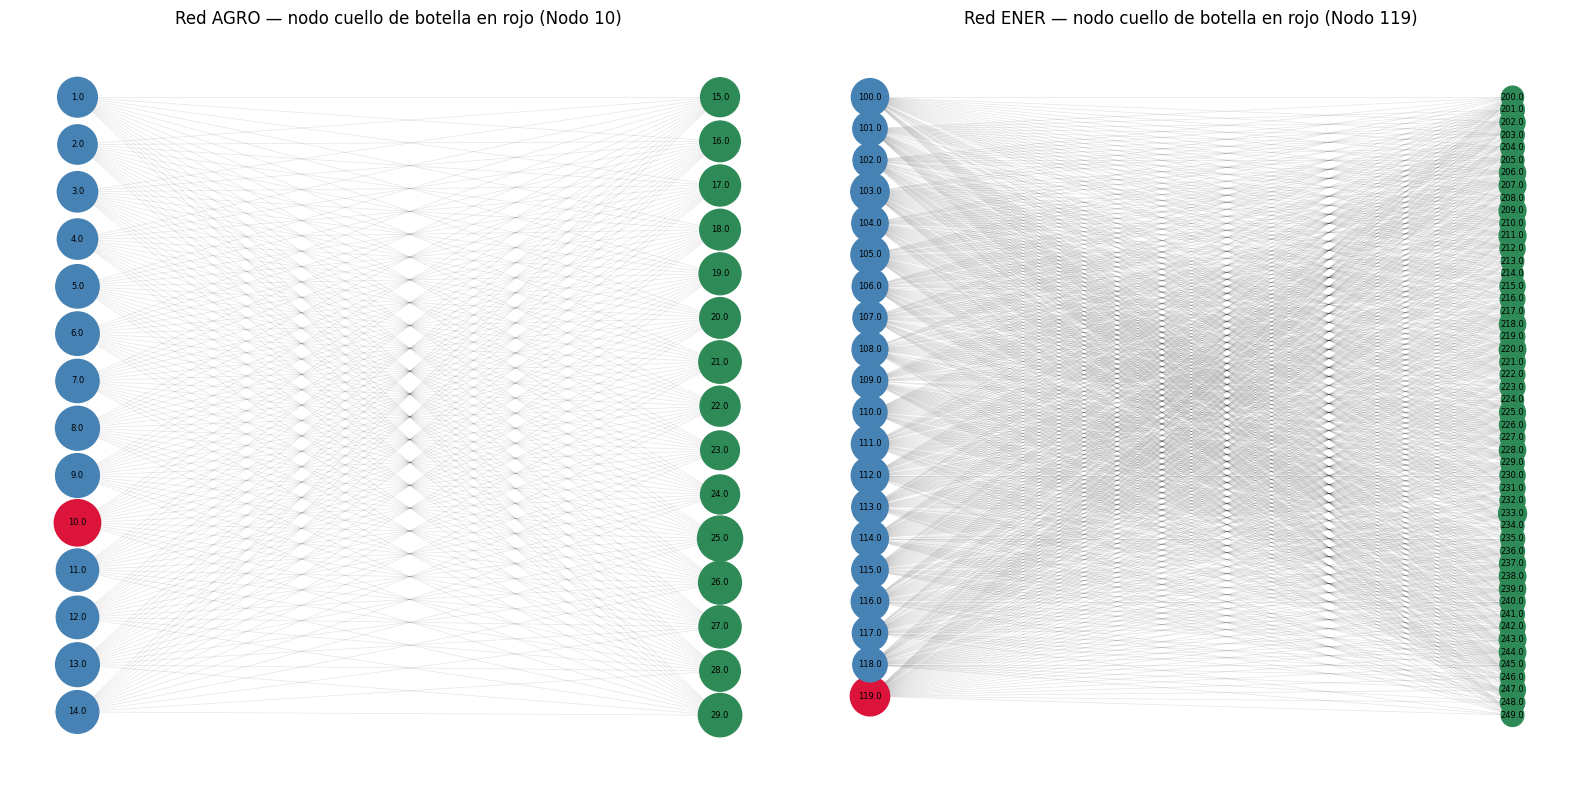

In [183]:
import matplotlib.pyplot as plt

def graficar_bipartito(G, df, total_w, bottleneck, titulo, ax):
    sources = sorted(set(df['Source_Node']))
    targets = sorted(set(df['Target_Node']))

    pos = {}
    for i, n in enumerate(sources):
        pos[n] = (0, -i * (len(targets) / len(sources)))
    for i, n in enumerate(targets):
        pos[n] = (1, -i)

    sizes = [80 + 6 * total_w[n] for n in G.nodes()]
    colors = ['crimson' if n == bottleneck else ('steelblue' if n in sources else 'seagreen')
              for n in G.nodes()]

    nx.draw_networkx_edges(G, pos, alpha=0.1, arrows=False, ax=ax, width=0.5)
    nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=6, ax=ax)
    ax.set_title(titulo)
    ax.axis('off')

total_w_agro = {n: peso_agro.set_index('Nodo').loc[n, 'Telemetria_total'] for n in G_agro.nodes()}
total_w_ener = {n: peso_ener.set_index('Nodo').loc[n, 'Telemetria_total'] for n in G_ener.nodes()}

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
graficar_bipartito(G_agro, agro_clean, total_w_agro, bottleneck_agro['Nodo'],
                    'Red AGRO — nodo cuello de botella en rojo (Nodo 10)', axes[0])
graficar_bipartito(G_ener, ener, total_w_ener, bottleneck_ener['Nodo'],
                    'Red ENER — nodo cuello de botella en rojo (Nodo 119)', axes[1])
plt.tight_layout()
plt.savefig('../results/figuras/fase3_grafos_bipartitos.png', dpi=120, bbox_inches='tight')
plt.show()

In [184]:
metricas = pd.concat([
    dc_agro.merge(peso_agro, on='Nodo').assign(Dataset='AGRO'),
    dc_ener.merge(peso_ener, on='Nodo').assign(Dataset='ENER'),
], ignore_index=True)
metricas['Betweenness'] = 0.0
metricas.to_csv('../results/metricas_centralidad.csv', index=False)
metricas.head()

,Nodo,Degree_centrality,Tipo,Telemetria_saliente,Telemetria_entrante,Telemetria_total,Dataset,Betweenness
0,4.0,0.535714,Source,127,0,127,AGRO,0.0
1,6.0,0.535714,Source,150,0,150,AGRO,0.0
2,9.0,0.535714,Source,152,0,152,AGRO,0.0
3,1.0,0.535714,Source,123,0,123,AGRO,0.0
4,2.0,0.535714,Source,120,0,120,AGRO,0.0


### Respuesta Tarea 5

Construimos dos grafos dirigidos (`AGRO`, 29 nodos/210 aristas; `ENER`, 70 nodos/865 aristas)
sobre `Source_Node`/`Target_Node`, ponderados por volumen de lecturas de telemetría. Ambos
resultaron ser **bipartitos de 2 capas**: ningún nodo es Source y Target a la vez, así que todo
camino tiene longitud 1 y la **Betweenness Centrality da 0 en todos los nodos de ambos grafos**
en la versión dirigida, un hallazgo estructural, no un error.

La Degree Centrality sin ponderar tampoco sirve en `AGRO`, porque ese grafo es bipartito
**completo** (densidad 100%), todos los sensores Source quedan empatados con la misma
centralidad. En `ENER` sí aporta algo de información porque la red es densa pero no completa.

Como verificación de robustez, también calculamos Betweenness sobre la versión **no dirigida**
del grafo (estándar y con la fórmula específica `nx.bipartite`), siguiendo la práctica habitual
en literatura de redes bipartitas de dos modos. En AGRO confirma el mismo resultado (todos los
Source empatados, todos los Target empatados), no hay forma estructural de distinguir un nodo
de otro en un bipartito completo. En ENER, el Nodo 119 vuelve a ganar con ambos métodos.

La visualización confirma los hallazgos: en AGRO todos los nodos Source lucen estructuralmente
iguales, y el cuello de botella solo se distingue por el tamaño (volumen de telemetría), no por
su posición en la red.

**Nodo Cuello de Botella (conclusión final:)**

- **AGRO: Nodo 10**, respaldado únicamente por volumen de telemetría (172 lecturas), ya que
  ninguna métrica estructural distingue nodos en este grafo completo. Es el mismo nodo que en la
  Tarea 1 salió como outlier geográfico de NDVI bajo, vale la pena cruzar este hallazgo con
  Fase 4 / P2.
- **ENER: Nodo 119**, respaldado por **tres métricas independientes y convergentes**: mayor
  Degree Centrality (0.71), mayor volumen de telemetría (120 lecturas), y mayor Betweenness
  Centrality no dirigida. Es el candidato más sólido de los dos grafos para responder P1 en la
  Fase 4, que pregunta explícitamente por "el nodo con mayor Betweenness Centrality".